# ⚡ Ontario's Energy Mix: The Accelerating Reliance on Natural Gas (2015 - 2026)

In 2014, Ontario completely phased out coal from its energy mix to pave the way for a cleaner grid. This analysis focuses on Ontario's electricity grid evolution starting in 2015, evaluating:
* Overall trends in electricity **Demand** vs. **Generation** over time.
* A granular breakdown of each fuel's structural output and percentage contribution.
* How the grid responds to escalating baseline demand and seasonal peaking events.

**Technical Stack:**

| Layer | Tools & Techniques |
|---|---|
| **Data Ingestion** | Python (`requests`, `xml.etree.ElementTree`, `pandas`) — automated extraction from IESO's XML & CSV report endpoints |
| **Database** | SQL Server — schema design, data integrity validation, and metric aggregation via CTEs and window functions |
| **Analysis & Visualization** | Python (`pandas`, `seaborn`, `plotly`) |
| **Environment** | Containerized with Docker for one-command, reproducible setup |

*Data sourced from [IESO's public reports](https://reports-public.ieso.ca/public/) (Generator Output by Fuel Type Monthly, and Hourly Demand Reports), retrieved June 29, 2026.*

## 🔑 Key Findings

**Ontario's electricity grid has quietly shifted Natural Gas from a flexible peaking resource into a structural baseload fallback — driven by both rising demand and a temporary loss of nuclear capacity.**

- **Demand entered a sharp structural climb starting in 2024**, breaking years of relative stability in the 12-month rolling average.
- **Gas absorbed essentially all of this growth.** From Jan 2024–May 2026, total generation rose +1,138 GWh while Gas output alone rose +1,232 GWh — more than accounting for the increase.
- **Gas also covered most of the output lost during Ontario's Nuclear Refurbishment Program** (2020–2023), when Nuclear output fell -1,387 GWh against a total system drop of just -251 GWh.
- **Gas's share of generation rises sharply with demand stress** — from 7.8% in low-demand months, to 12.8% in high-demand months, to 15.8% in the top 10 most extreme peak months, and to as much as 18.0% in the top 5.

**NOTE**: The visuals inside the `main.ipynb` notebook are rendered as png images because plotly javascript charts don't render on Github. Each plotly chart has a link to the interactive version under it.

*(Full methodology, charts, and limitations below.)*

In [1]:
# Core data manipulation and database connection
import os
import pandas as pd
import numpy as np
from sqlalchemy import create_engine
import urllib

# Visualization libraries
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

# Ensure the GitHub Pages chart output folder exists
os.makedirs('docs/charts', exist_ok=True)

# Rendering plotly charts as png images because plotly javascript charts don't render on Github
# A link to the interactive version of the chart has been put under each plotly chart
# If you want interactive charts right in the notebook, comment the two lines below
import plotly.io as pio
pio.renderers.default = 'png'

# Standardized color palette for narrative consistency across all charts
GLOBAL_COLOR_PALETTE = {
    # Fuels
    'Gas': '#D92525',          # Red
    'Nuclear': '#2E2252',      # Dark, rich blue/purple
    'Hydro': '#554B8D',        # Lighter but saturated blue/purple
    'Wind': '#867CAE',         # Soft blue/purple
    'Biofuel': '#BCB8CD',      # Desaturated, greyish blue/purple
    'Solar': '#D8D5DF',        # Very light, faded greyish blue/purple

    # System Totals
    'Demand': '#333333',       # Dark Grey
    'Generation': '#888888',   # Grey
}

In [2]:
# Creating a connection to the SQL Server Database where the demand and generation data lives
SERVER = 'localhost'
DATABASE = 'ontario_energy'
USERNAME = 'SA'
PASSWORD = 'Ontario_Energy_Mix@15_26'  # Local dev only — matches docker-compose.yml; change if you update the container password

conn_str = (f"DRIVER={{ODBC Driver 17 for SQL Server}};"
            f"SERVER={SERVER},1433;"
            f"DATABASE={DATABASE};"
            f"Uid={USERNAME};"
            f"Pwd={PASSWORD};"
            f"Encrypt=yes;"
            f"TrustServerCertificate=yes;")

params = urllib.parse.quote_plus(conn_str)
engine_url = f"mssql+pyodbc:///?odbc_connect={params}"

# Creating SQLAlchemy engine that serves as the core interface to the database
engine = create_engine(engine_url)

## 0. Data Integrity Checks
Before we dive into the analysis of data, let's make sure the data is clean and has no anomalies.

In [3]:
# Executing the 'data_integrity.sql' script via the database engine
with open('sql_scripts/data_integrity.sql', 'r') as sql_file:
    sql = sql_file.read()

scripts = [s.strip() for s in sql.split(';\nGO') if s.strip()]

for script in scripts:
    df = pd.read_sql(script, con=engine)
    display(df)

,generation_null_records
0,0


,demand_null_records
0,0


,duplicate_generation_records
0,0


,duplicate_demand_records
0,0


,number_of_missing_generation_months
0,0


,number_of_missing_demand_months
0,0


,distinct_fuel_types
0,BIOFUEL
1,GAS
2,HYDRO
3,NUCLEAR
4,SOLAR
5,WIND


,month_in_demand_not_in_generation
0,2026-06-01


,month_in_generation_not_in_demand


### Everything looks good
* There are **no NULLs**
* There are **no Duplicates**
* Both 'demand' and 'generation' tables have **a continuous range of months**
* There are **six different fuel types** and they stay **consistent** throughout the 'generation' data

### One thing to note
* The 'demand' table might have data for more months than the 'generation' table, which it does in this case
* For this particular data ingestion, 'demand' has data for June 2026, but 'generation' does not
* And since the data for June 2026 is incomplete in 'demand' table (as the month was ongoing at the time when the data was sourced), it should be removed
* To solve these problems, **two VIEWS** have been created from the 'demand' TABLE
    1. **'demand_complete_months'**: a demand view for standalone analysis of demand data which only contains completed months of demand data
    2. **'demand_matching_generation_range'**: a demand view for analysis of demand data along with generation data which only contains months of demand data that are also present in the generation table

### Let's get Analyzing

## 1. Direct Electricity Demand Over Time
We begin by plotting the raw hourly demand metrics aggregated by month to establish a baseline look at Ontario's power consumption.

In [4]:
# Fetch raw data from SQL Server view 'demand_complete_months'
df_demand = pd.read_sql('demand_complete_months', con=engine)
df_demand.head()

,month,total_demand_gwh,peak_demand_gw
0,2015-01-01,13119.979,21.814
1,2015-02-01,12302.279,21.494
2,2015-03-01,12044.976,20.827
3,2015-04-01,10404.961,18.462
4,2015-05-01,10547.132,19.158


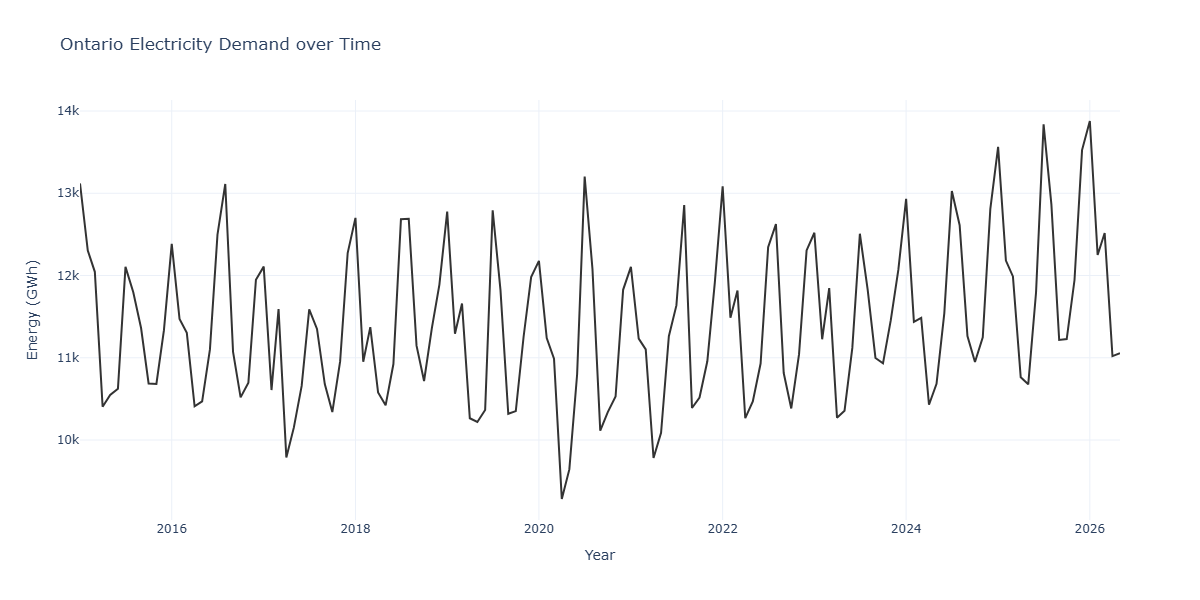

In [5]:
# Plotting raw monthly demand to diagnose initial visual trends

line = px.line(
    data_frame=df_demand,
    x='month',
    y='total_demand_gwh',
    labels={
        'month': 'Year',
        'total_demand_gwh': 'Energy (GWh)',
    },
    title='Ontario Electricity Demand over Time',
    width=1200,
    height=600,
)

line.update_traces(
    line_color=GLOBAL_COLOR_PALETTE['Demand'],
    hovertemplate="<b>%{y:,.2f} GWh</b>",
)

line.update_layout(
    template='plotly_white',
    hovermode='x unified',
)

# Exports a standalone interactive HTML file for the GitHub Pages chart index
line.write_html('docs/charts/demand_over_time.html', include_plotlyjs='cdn', full_html=True)
line.show()

▶ [View interactive version](https://ksprihar.github.io/ontario-energy-mix/charts/demand_over_time.html)

### Filtering Out Seasonal Noise
At first look, this chart just looks like noise. But on closer inspection, we find that the fluctuations are actually highly seasonal and cyclical, happening around the same time each year:
* **The Lows:** Occur in April, May, September, or October, when the weather is relatively pleasant and heating/cooling requirements are minimal.
* **The Highs:** Peak sharply in July (extreme summer heat driving AC units) or January (extreme winter cold).

Analyses performed on aggressive seasonal fluctuations can be highly volatile. To isolate the true macro-structural trends of the grid, we apply a **12-month rolling moving average** calculated via SQL Window functions. Moving averages are lagging indicators, but they eliminate seasonal volatility.

In [6]:
# Executing the 'demand_rolling_avg.sql' script via the database engine
with open('sql_scripts/demand_rolling_avg.sql', 'r') as sql_file:
    sql = sql_file.read()

df_demand_roll = pd.read_sql(sql, con=engine)
df_demand_roll.sample(5)

,month,total_demand_gwh,rolling_avg_demand_12m
63,2020-04-01,9282.854,11066.662500
41,2018-06-01,10923.446,11177.759083
127,2025-08-01,12864.235,11995.070750
84,2022-01-01,13085.388,11235.370000
13,2016-02-01,11471.763,11287.179333


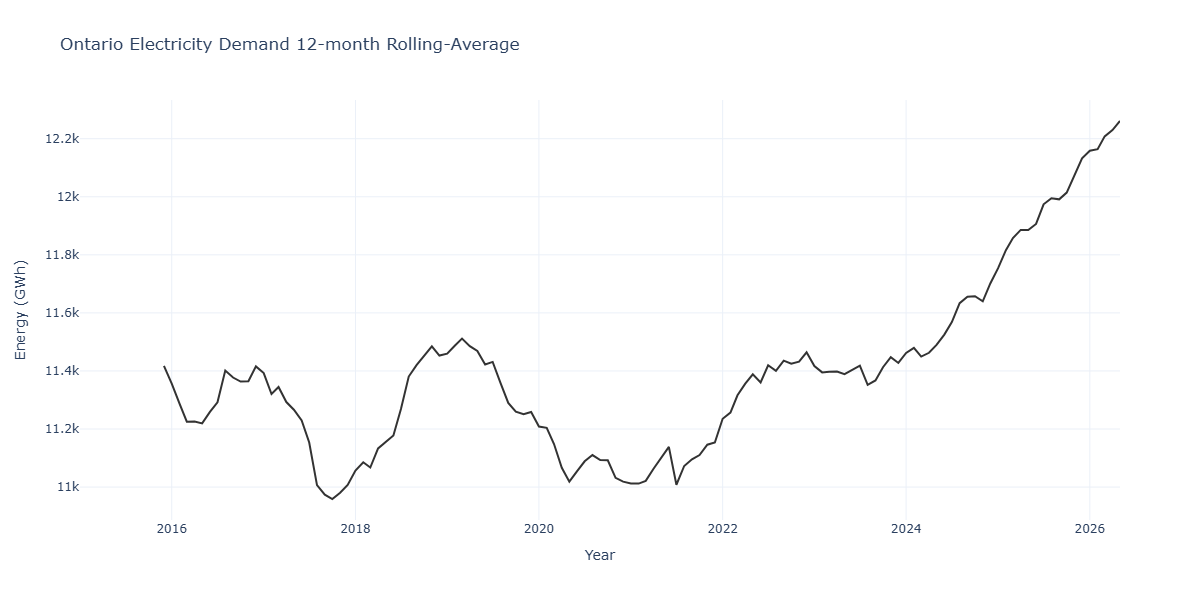

In [7]:
# Visualizing the smooth macro trend of Ontario's electricity consumption

line = px.line(
    data_frame=df_demand_roll,
    x='month',
    y='rolling_avg_demand_12m',
    labels={
        'month': 'Year',
        'rolling_avg_demand_12m': 'Energy (GWh)',
    },
    title='Ontario Electricity Demand 12-month Rolling-Average',
    width=1200,
    height=600,
)

line.update_traces(
    line_color=GLOBAL_COLOR_PALETTE['Demand'],
    hovertemplate="<b>%{y:,.2f} GWh</b>",
)

line.update_layout(
    template='plotly_white',
    hovermode='x unified',
)

# Exports a standalone interactive HTML file for the GitHub Pages chart index
line.write_html('docs/charts/demand_rolling_avg.html', include_plotlyjs='cdn', full_html=True)
line.show()

▶ [View interactive version](https://ksprihar.github.io/ontario-energy-mix/charts/demand_rolling_avg.html)

## 2. Do Generation Graphs Tell a Similar Story?
The 12-month moving average transforms the narrative. Until the end of 2023, total demand oscillated around stable, comparable levels. However, starting in **2024**, demand initiated a significant and steep upward spike.

Let's overlay the 12-month rolling averages of both **Total Demand** and **Total Generation** on a unified chart to see if supply scales dynamically alongside consumption.

In [8]:
# Executing the 'generation_by_fuel_rolling_avg.sql' script via the database engine
with open('sql_scripts/generation_by_fuel_rolling_avg.sql', 'r') as sql_file:
    sql = sql_file.read()

# The SQL script gives us the rolling average by each fuel type
df_gen_roll = pd.read_sql(sql, con=engine)
df_gen_roll['fuel'] = df_gen_roll['fuel'].str.title()

df_gen_roll.sample(5)

,month,fuel,output_gwh,rolling_avg_fuel_12m
456,2021-05-01,Biofuel,28.09,30.384167
121,2016-09-01,Gas,1091.33,1097.970833
9,2015-02-01,Nuclear,7731.11,NaN
116,2016-08-01,Hydro,2708.50,3040.296667
340,2019-09-01,Solar,71.19,53.927500


In [9]:
# We can add up the individual fuel averages to get the total generation rolling average over 12 months
df_gen_month_roll = df_gen_roll.groupby('month', as_index=False).agg(
    total_generation=('output_gwh', pd.Series.sum),
    rolling_avg_gen_12m=('rolling_avg_fuel_12m', pd.Series.sum)
).replace(0, np.nan)
# Replacing the 0 values (that occur because of the NULLS in the SQL output) with NaN so that they don't show in the charts

# df_gen_month_roll can be merged with df_demand_roll to get both rolling averages in the same DataFrame
df_roll = df_gen_month_roll.merge(df_demand_roll, how='inner', on='month')

df_roll.sample(5)

,month,total_generation,rolling_avg_gen_12m,total_demand_gwh,rolling_avg_demand_12m
121,2025-02-01,13351.58,13166.150833,12181.126,11815.993167
130,2025-11-01,12726.13,13504.319167,11945.010,12072.394833
55,2019-08-01,12614.27,12432.462500,11825.052,11359.164667
1,2015-02-01,13937.08,NaN,12302.279,NaN
78,2021-07-01,12369.11,11762.983333,11636.443,11008.062917


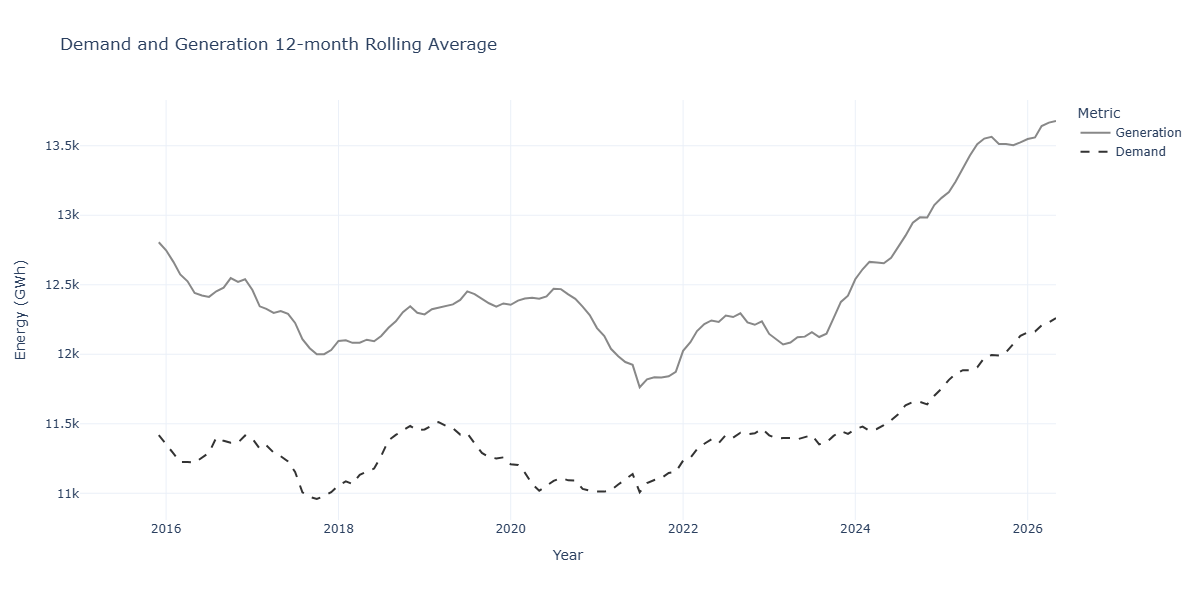

In [10]:
# Overlaying demand and generation tracking metrics on a single chart

line = px.line(
    data_frame=df_roll,
    x='month',
    y=['rolling_avg_gen_12m', 'rolling_avg_demand_12m'],
    labels={
        'rolling_avg_gen_12m': 'Generation',
        'rolling_avg_demand_12m': 'Demand',
        'month': 'Year',
        'value': 'Energy (GWh)',
        'variable': 'Metric'
    },
    color_discrete_map={
        'rolling_avg_gen_12m': GLOBAL_COLOR_PALETTE['Generation'],
        'rolling_avg_demand_12m': GLOBAL_COLOR_PALETTE['Demand'],
    },
    title='Demand and Generation 12-month Rolling Average',
    width=1200,
    height=600,
)


line.update_traces(
    selector=dict(name='rolling_avg_gen_12m'),
    name='Generation',
    legendgroup='Generation',
)

line.update_traces(
    selector=dict(name='rolling_avg_demand_12m'),
    line=dict(dash='dash'),
    name='Demand',
    legendgroup='Demand',
)

line.update_traces(
    hovertemplate="<b>%{y:,.2f} GWh</b>",
)

line.update_layout(
    template='plotly_white',
    hovermode='x unified',
)

# Exports a standalone interactive HTML file for the GitHub Pages chart index
line.write_html('docs/charts/demand_generation_rolling_avg.html', include_plotlyjs='cdn', full_html=True)
line.show()

▶ [View interactive version](https://ksprihar.github.io/ontario-energy-mix/charts/demand_generation_rolling_avg.html)

## 3. Dissecting the Generation Mix: Fuel-by-Fuel Analysis
Demand and generation are locked in a near-identical climb. To understand *which* fuels are actively scaling up to support this demand hike, we must separate the total generation profile into its standalone fuel assets.

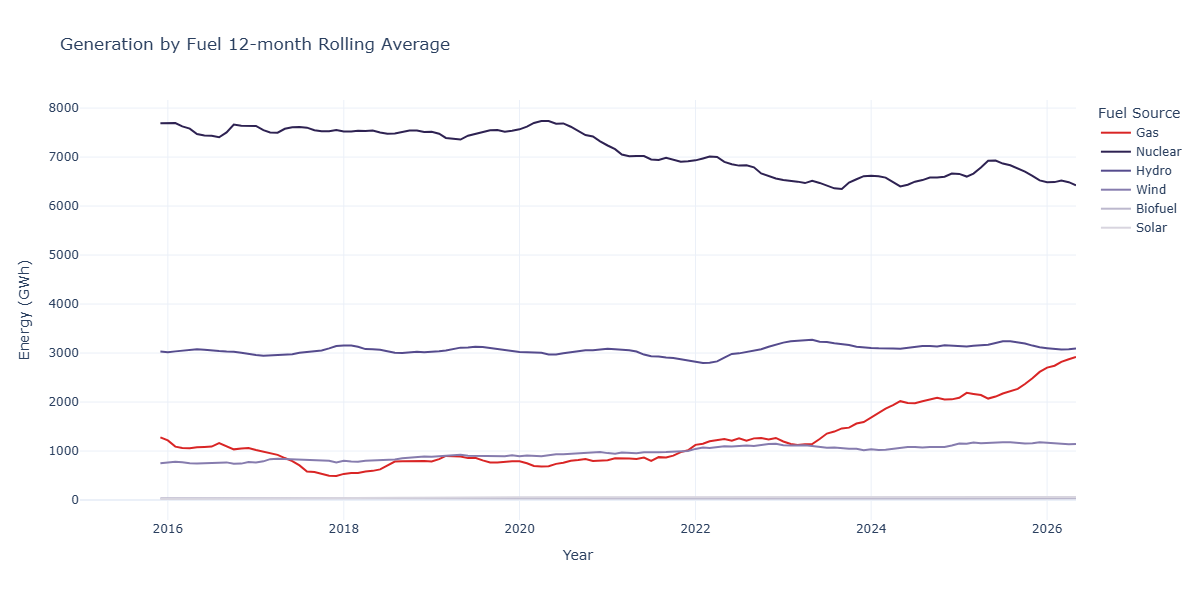

In [11]:
# Rendering individual rolling averages for all fuel sources

line = px.line(
    data_frame=df_gen_roll,
    x='month',
    y='rolling_avg_fuel_12m',
    color='fuel',
    labels={
        'month': 'Year',
        'rolling_avg_fuel_12m': 'Energy (GWh)',
        'fuel': 'Fuel Source'
    },
    color_discrete_map=GLOBAL_COLOR_PALETTE,
    title='Generation by Fuel 12-month Rolling Average',
    category_orders={
        'fuel': ['Gas', 'Nuclear', 'Hydro', 'Wind', 'Biofuel', 'Solar']
    },
    width=1200,
    height=600,
)

line.update_traces(
    hovertemplate="<b>%{y:,.2f} GWh</b>",
)

line.update_layout(
    template='plotly_white',
    hovermode='x unified',
    hoverlabel=dict(bgcolor='rgba(255,255,255,0.7)'),
)

# Exports a standalone interactive HTML file for the GitHub Pages chart index
line.write_html('docs/charts/fuel_rolling_avg.html', include_plotlyjs='cdn', full_html=True)
line.show()

▶ [View interactive version](https://ksprihar.github.io/ontario-energy-mix/charts/fuel_rolling_avg.html)

### Structural Performance by Fuel Class:
1. **Biofuel:** Negligible baseline footprint.
2. **Solar:** Negligible footprint on this scale (Note: This tracks *on-grid* solar generation only; embedded distributed local solar is excluded).
3. **Wind:** Displays a slow, continuous creep upward over the last 10 years.
4. **Hydro:** Remains remarkably constant and highly reliable over the decade.
5. **Nuclear:** Stays constant until 2020, experiences a distinct structural drop through the end of 2023, and subsequently levels off.
6. **Gas:** The most dynamic fuel in the mix. It dropped sharply until 2018, climbed steadily from 2018 to 2023, and expanded aggressively over the last two years. No other asset matches the percentage increase seen in Gas.

Is natural gas explicitly driving the grid's expansion? Let's isolate Total Generation against Gas Generation using a dual-axis layout to test this relationship.

In [12]:
# Pivoting the generation DataFrame to get each fuel its own column. This is done to extract exact numbers from the DataFrame in specified periods of time later on
df_gen_roll_pivot = df_gen_roll.pivot(
    columns='fuel',
    index='month',
    values='rolling_avg_fuel_12m',
).reset_index()
df_gen_roll_pivot.sample(5)

fuel,month,Biofuel,Gas,Hydro,Nuclear,Solar,Wind
6,2015-07-01,NaN,NaN,NaN,NaN,NaN,NaN
19,2016-08-01,40.548333,1161.662500,3040.296667,7404.420000,37.194167,768.784167
97,2023-02-01,25.742500,1145.151667,3241.200833,6522.980000,61.811667,1112.072500
132,2026-01-01,29.782500,2702.612500,3099.710833,6487.530833,60.195000,1168.575000
3,2015-04-01,NaN,NaN,NaN,NaN,NaN,NaN


In [13]:
# Merging all the fuels' output rolling averages with total demand and total generation
df_roll_with_fuels = df_roll.merge(df_gen_roll_pivot, how='inner', on='month')
df_roll_with_fuels.sample(5)

,month,total_generation,rolling_avg_gen_12m,total_demand_gwh,rolling_avg_demand_12m,Biofuel,Gas,Hydro,Nuclear,Solar,Wind
127,2025-08-01,13839.12,13563.580000,12864.235,11995.070750,31.945000,2219.303333,3239.125833,6831.499167,61.901667,1179.805000
22,2016-11-01,12015.50,12520.040000,10697.636,11364.717083,42.321667,1051.295833,3004.833333,7639.219167,38.750000,743.620000
51,2019-04-01,11311.28,12349.589167,10264.505,11485.500833,32.421667,889.296667,3089.323333,7370.318333,49.028333,919.200833
20,2016-09-01,12024.19,12478.850833,11072.260,11377.429000,40.920833,1097.970833,3030.867500,7502.425000,38.352500,768.314167
108,2024-01-01,14827.85,12539.580000,12932.636,11461.970667,29.755833,1690.177500,3103.470833,6617.149167,61.232500,1037.794167


## 4. Quantifying the Gas Link: Dual-Axis Correlation
To evaluate if gas matches the trend lines of our growing grid, we map Total Generation (Left Axis: 11,000 to 14,000 GWh) against Gas Generation (Right Axis: 0 to 3,000 GWh). Both axes capture an identical range scale of **3,000 GWh**, preserving accurate slope visual comparisons.

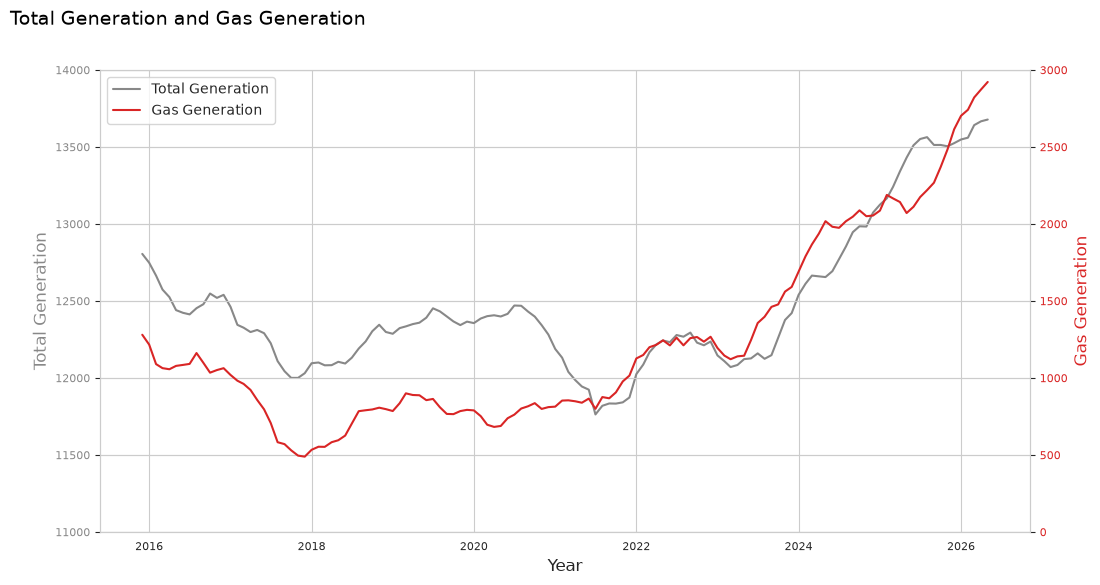

In [14]:
# Initializing dual-axis plotting with synchronized y-axis scales (3,000 GWh span each)
# Verifying visual symmetry between gas adjustments and total grid changes

plt.figure(figsize=(12,6), dpi=100)

with sns.axes_style('whitegrid'):
    ax1 = plt.gca()
    ax2 = ax1.twinx()

    sns.lineplot(
        data=df_roll_with_fuels,
        x='month',
        y='rolling_avg_gen_12m',
        ax=ax1,
        color=GLOBAL_COLOR_PALETTE['Generation'],
        label='Total Generation',
    )

    ax1.set_xlabel('Year', fontsize=12)
    ax1.set_ylabel('Total Generation', fontsize=12, color=GLOBAL_COLOR_PALETTE['Generation'])
    ax1.set(ylim=(11000, 14000))

    ax1.tick_params(labelsize=8)
    ax1.tick_params(axis='y', labelcolor=GLOBAL_COLOR_PALETTE['Generation'])

    sns.lineplot(
        data=df_roll_with_fuels,
        x='month',
        y='Gas',
        ax=ax2,
        color=GLOBAL_COLOR_PALETTE['Gas'],
        label='Gas Generation',
    )

    ax2.set_ylim(0, 3000)
    ax2.set_ylabel('Gas Generation', fontsize=12, color=GLOBAL_COLOR_PALETTE['Gas'])
    ax2.tick_params(axis='y', labelsize=8, labelcolor=GLOBAL_COLOR_PALETTE['Gas'])

    h1, l1 = ax1.get_legend_handles_labels()
    h2, l2 = ax2.get_legend_handles_labels()
    ax2.legend(h1+h2, l1+l2, loc='upper left')
    ax1.get_legend().remove()

plt.suptitle('Total Generation and Gas Generation', x=0.05, ha='left', fontsize=14)
plt.show()

### Gas: A Spitting Image of the Total Generation
Except for a divergence between 2020 and 2022, Gas tracks the absolute structural fluctuations of Total Generation with extreme precision. Because Nuclear, Hydro, and Wind act as fixed baseload sources, Gas functions as the system's absolute variance sponge.

We can see from the chart that Gas is what has made up for all the increasing Total output since the end of 2023.
**Let’s take a look at the exact numbers since January 2024**, which is where the demand and generation started to climb steeply.

In [15]:
# Cutting off the df_roll_with_fuels dataframe to only include dates after Jan 2024, which is where the spike in demand and generation occured
df_change = df_roll_with_fuels.loc[df_roll_with_fuels['month'] >= pd.to_datetime('2024-01-01').date()].sort_values('month', ascending=True)[['rolling_avg_gen_12m', 'rolling_avg_demand_12m', 'Gas']]

# Renaming the columns
df_change.rename(
    columns={
        'rolling_avg_gen_12m': 'Change in Generation',
        'rolling_avg_demand_12m': 'Change in Demand',
        'Gas': 'Change in Gas Output',
    },
    inplace=True,
)

# Getting the difference in the last and first row of data. Data is already ordered by month.
(df_change.iloc[-1] - df_change.iloc[0]).to_frame()

,0
Change in Generation,1138.390000
Change in Demand,799.028083
Change in Gas Output,1231.771667


### Evaluating the Macro Data (January 2024 – May 2026)
* **Change in Total Generation:** +1,138.39 GWh
* **Change in Total Demand:** +799.03 GWh
* **Change in Gas Output:** +1,231.77 GWh

During this intense growth period, the numbers, just like our chart, tell us that Gas is what made up for all the increase in Total Generation.

The only time gas wasn’t tracking total generation was between 2020 and 2022, when the total output was going down but gas continued to climb. Below is a snippet from the **'Total Generation and Gas Generation'** chart above to highlight that exact period of divergence.

![image.png](img/divergence.png)

#### Why the divergence?
Taking a look at the line chart above with all 6 fuels, we see that Nuclear output was dropping during this period. Nuclear output fell from May 2020 to September 2023. Why did Nuclear drop? And was Gas the fuel to make up for this drop as well? Just like it has made up for the hiking demand the past couple of years? Let’s see.

Let’s get the exact change in rolling averages between these dates **(May 2020 to Sep 2023)** for the **Total output, Nuclear, Hydro, Gas, and Wind**. We will ignore Biofuel and Solar since they are negligible compared to the other fuels.

In [16]:
# Cutting off the df_roll_with_fuels dataframe to only include dates between May 2020 to September 2023, which is the period Nuclear output was dropping
df_nuclear = df_roll_with_fuels.loc[(df_roll_with_fuels['month'] >= pd.to_datetime('2020-05-01').date()) & (df_roll_with_fuels['month'] <= pd.to_datetime('2023-09-01').date())].sort_values('month', ascending=True)[['rolling_avg_gen_12m', 'Nuclear', 'Gas', 'Hydro', 'Wind']]

# Renaming the columns
df_nuclear.rename(
    columns={
        'rolling_avg_gen_12m': 'Change in Total Output',
        'Nuclear': 'Change in Nuclear Output',
        'Gas': 'Change in Gas Output',
        'Hydro': 'Change in Hydro Output',
        'Wind': 'Change in Wind Output',
    },
    inplace=True,
)

# Getting the difference in the last and first row of data. Data is already ordered by month.
(df_nuclear.iloc[-1] - df_nuclear.iloc[0]).to_frame()

,0
Change in Total Output,-251.139167
Change in Nuclear Output,-1387.257500
Change in Gas Output,773.521667
Change in Hydro Output,217.402500
Change in Wind Output,146.320000


### Evaluating the Nuclear Divergence Window (May 2020 – September 2023)
* **Change in Total Output:** -251.14 GWh
* **Change in Nuclear Output:** -1,387.26 GWh
* **Change in Gas Output:** +773.52 GWh
* **Change in Hydro Output:** +217.40 GWh
* **Change in Wind Output:** +146.32 GWh

Between 2020 and 2022, total grid output flattened, yet gas output climbed. This matches the timeline of Ontario’s multi-billion dollar **Nuclear Refurbishment Program** aimed at extending reactor lifespans by 30+ years. **When baseload Nuclear dropped, it was again Gas stepped in to preserve grid integrity.**

## 5. Evolution of Annual Fuel Share Contributions
To see the net structural impact of these changes, we review how each fuel type's total percentage contribution to the grid shifts year-over-year using a 100% Stacked Area chart.

In [17]:
# Executing 'fuel_contribution_yearly.sql' to pull percentage breakdowns
with open('sql_scripts/fuel_contribution_yearly.sql', 'r') as sql_file:
    sql = sql_file.read()

df_fuel_yearly_contri = pd.read_sql(sql, con=engine)
df_fuel_yearly_contri['fuel'] = df_fuel_yearly_contri['fuel'].str.title()
df_fuel_yearly_contri.sample(10)

,year,fuel,fuel_output,yearly_output,percentage_of_total_generation
59,2024,Solar,746.08,156884.27,0.48
54,2024,Gas,24655.52,156884.27,15.72
33,2020,Wind,11757.18,147385.07,7.98
32,2020,Hydro,36935.24,147385.07,25.06
15,2017,Wind,9176.25,144368.21,6.36
50,2023,Hydro,37369.61,149052.86,25.07
36,2021,Gas,12183.27,142479.18,8.55
19,2018,Nuclear,90149.17,147580.83,61.08
13,2017,Nuclear,90618.30,144368.21,62.77
10,2016,Biofuel,491.43,150475.07,0.33


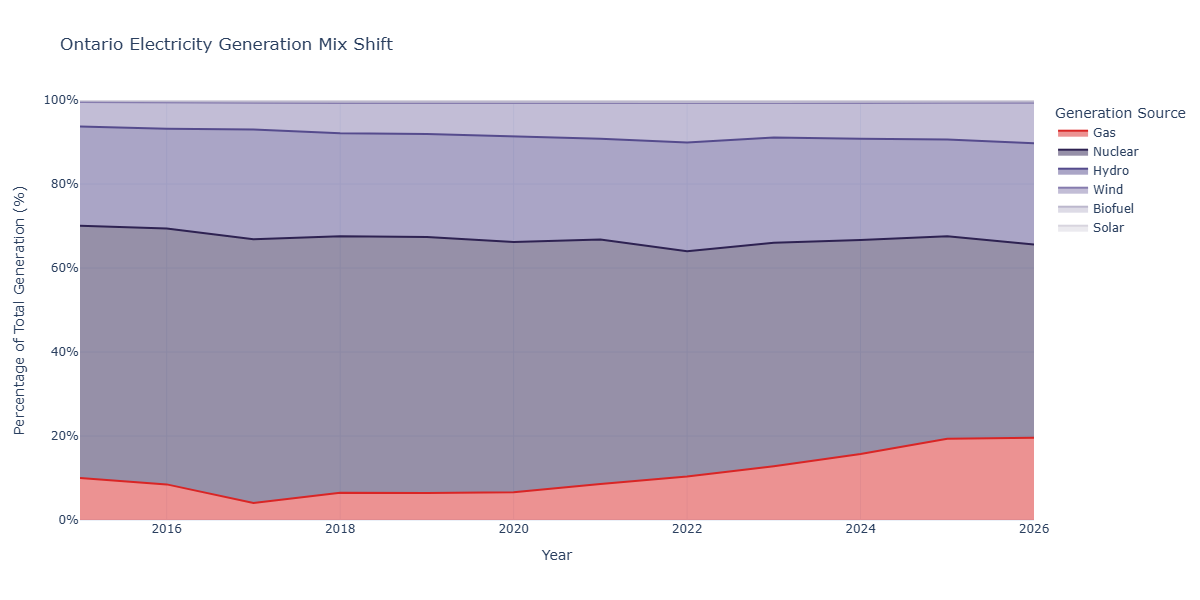

In [18]:
# Creating a stacked 100% area chart that tracks year by year variation in each fuel's contribution to the grid

area = px.area(
    data_frame=df_fuel_yearly_contri,
    x='year',
    y='percentage_of_total_generation',
    color='fuel',
    title='Ontario Electricity Generation Mix Shift',
    labels={
        'percentage_of_total_generation': 'Percentage of Total Generation (%)',
        'year': 'Year',
        'fuel': 'Generation Source'
    },
    color_discrete_map=GLOBAL_COLOR_PALETTE,
    width=1200,
    height=600,
)

area.update_traces(
    hovertemplate="<b>%{y:.2f} %</b>",
)

area.update_layout(
    template='plotly_white',
    yaxis=dict(range=[0, 100], ticksuffix='%'),
    hovermode='x unified',
)

# Exports a standalone interactive HTML file for the GitHub Pages chart index
area.write_html('docs/charts/stacked_area.html', include_plotlyjs='cdn', full_html=True)
area.show()

▶ [View interactive version](https://ksprihar.github.io/ontario-energy-mix/charts/stacked_area.html)

### The Chart Confirms the Numbers
The shrinkage of the Nuclear band directly mirrors the expansion of the Natural Gas footprint and confirms that Natural Gas is indeed what fills up the gap that Nuclear is leaving behind.

## 6. Stress-Testing the Grid: The Peak Demand Hypothesis
The historical trend line analysis demonstrates that Gas handles long-term baseload drops and multi-year demand expansions. But what happens during day-to-day, hour-to-hour peak stress events (e.g., extreme hot summer days when millions of air conditioning units initialize simultaneously)?

Even though our current data is structured at a monthly resolution, we can still track the **absolute peak hour demand recorded for each month**.

**Our Hypothesis:** If Ontario depends on gas infrastructure to absorb peak loads, then months with higher peak demand metrics will exhibit a higher percentage contribution of gas to the total output.

### Milestone 1: Top 50th Percentile Peak Months vs. Bottom Months
We split our historical tracking months into two equal halves using `PERCENT_RANK()` based on peak demand magnitude.

In [19]:
# Executing 'top_50th_percentile.sql' script via the database engine
with open('sql_scripts/top_50th_percentile.sql', 'r') as sql_file:
    sql = sql_file.read()

df_top_50th_percentile = pd.read_sql(sql, con=engine)
df_top_50th_percentile

,month_category,fuel_category,fuel_category_output,month_category_total,percentage_of_total_generation
0,Top Months,Gas,115087.78,900746.27,12.78
1,Top Months,Others,785658.49,900746.27,87.22
2,Bottom Months,Gas,63865.24,818359.33,7.80
3,Bottom Months,Others,754494.09,818359.33,92.20


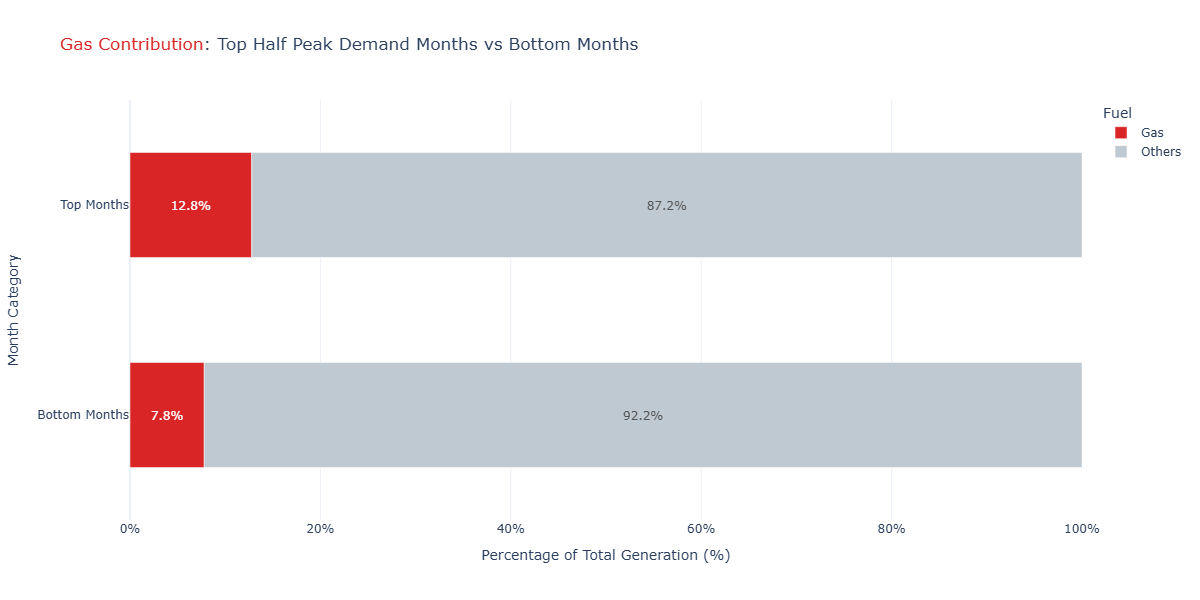

In [20]:
# Creating a horizontal bar chart to compare Gas' contribution to the grid vs all other fuels for Top and Bottom 50th percentile peak demand months
bar = px.bar(
    data_frame=df_top_50th_percentile,
    x='percentage_of_total_generation',
    y='month_category',
    color='fuel_category',
    color_discrete_map={
        'Gas': GLOBAL_COLOR_PALETTE['Gas'],
        'Others': '#BFC9D1'
    },
    labels={
        'month_category': 'Month Category',
        'percentage_of_total_generation': 'Percentage of Total Generation (%)',
        'fuel_category': 'Fuel'
    },
    category_orders={
        'month_category': ['Top Months', 'Bottom Months']
    },
    title=f"<span style='color:{GLOBAL_COLOR_PALETTE['Gas']}'>Gas Contribution</span>: Top Half Peak Demand Months vs Bottom Months",
    width=1200,
    height=600,
)

bar.update_traces(
    hovertemplate="<b>%{x:.2f}%</b>",
    texttemplate="%{x:.1f}%",          # Formats the label
    textposition="inside",             # Forces the label inside the segment
    insidetextanchor="middle",         # Centers the text within that segment
    textfont_color="#FFFFFF",
)

bar.update_traces(
    selector=dict(name="Others"),
    textfont_color="#555555",
)

bar.update_layout(
    bargap=0.5,
    template='plotly_white',
    xaxis=dict(range=[0, 100], ticksuffix='%'),
)

# Exports a standalone interactive HTML file for the GitHub Pages chart index
bar.write_html('docs/charts/gas_contribution_50th_percentile.html', include_plotlyjs='cdn', full_html=True)
bar.show()

▶ [View interactive version](https://ksprihar.github.io/ontario-energy-mix/charts/gas_contribution_50th_percentile.html)

The results validate our hypothesis: months falling within the top 50th percentile of peak demand display a gas contribution share of **12.8%**, compared to just **7.8%** in lower-demand months.

### Milestone 2: The Extreme Peak (Top 10 Months vs. All Other Months)
To confirm our hypothesis, we isolate the absolute **Top 10 highest peak-demand months** across our entire 10-year tracking window and contrast them against the rest of the timeline.

Let us also look at the **Top 5 months** data in addition to the Top 10 Months. Let's see what the data says.

In [21]:
# Executing the 'top_10_months.sql' script to get the exact months which had the highest peak demands in any hour
with open('sql_scripts/top_10_months.sql', 'r') as sql_file:
    sql = sql_file.read()

df_top_10_months = pd.read_sql(sql, con=engine)
df_top_10_months['top_months'] = pd.to_datetime(df_top_10_months['top_months'])
df_top_10_months['top_months'] = df_top_10_months['top_months'].dt.strftime('%B %Y')
df_top_10_months

,top_months
0,June 2025
1,August 2025
2,July 2025
3,July 2020
4,June 2024
5,August 2020
6,September 2023
7,July 2024
8,September 2018
9,September 2016


### A couple of noticeable points:
* As expected, most of the top 10 months are during Summers.
* Interestingly the top 3 months are all from the summer of 2025.
* There are 3 Septembers in the top 10 months. Curious.

Let's investigate these Septembers (2016, 2018, 2023) before moving on.

In [22]:
# Exploring if these Septembers are genuine data points before moving on with the investigation
# The idea is to look at the surrounding two months in either direction and see if September data is consistent.

df_septembers = df_demand.loc[df_demand['month'].dt.year.isin([2016, 2018, 2023]) & (df_demand['month'].dt.month.isin([7, 8, 9, 10, 11]))].sort_values('month', ascending=True)

df_septembers

,month,total_demand_gwh,peak_demand_gw
18,2016-07-01,12497.616,22.659
19,2016-08-01,13113.359,23.100
20,2016-09-01,11072.260,23.213
21,2016-10-01,10518.677,18.189
22,2016-11-01,10697.636,19.369
42,2018-07-01,12685.321,23.046
43,2018-08-01,12688.795,21.990
44,2018-09-01,11147.310,23.240
45,2018-10-01,10717.348,18.205
46,2018-11-01,11360.321,20.152


**A note on the September outliers:** three Septembers (2016, 2018, 2023) appear in the Top 10 despite September typically being a lower-demand month overall. A check against the surrounding months reveals this isn't a one-off blip — in **all three years**, September's peak-hour demand exceeds both July's and August's, even though September's *total* monthly demand is the lowest of the three. This rules out a simple data extraction error and suggests something structural rather than random: a plausible theory is a late-season heat event landing on a grid where full business/school activity has resumed (unlike August's quieter industrial schedule), spiking the peak even as average load stays low. Confirming this would require hourly-resolution data, which is outside the scope of this analysis — flagged here as a strong candidate for a future hourly-level extension.

Moving on with the original investigation.

In [23]:
# Executing 'top_10_months_data.sql' script via the database engine
with open('sql_scripts/top_10_months_data.sql', 'r') as sql_file:
    sql = sql_file.read()

df_top_10_peak = pd.read_sql(sql, con=engine)
df_top_10_peak

,month_category,fuel_category,fuel_category_output,month_category_total,percentage_of_total_generation
0,Top 10 Months,Gas,20691.79,131139.4,15.78
1,Top 10 Months,Others,110447.61,131139.4,84.22
2,Other Months,Gas,158261.23,1587966.2,9.97
3,Other Months,Others,1429704.97,1587966.2,90.03


In [24]:
# Executing a modified version of 'top_10_months_data.sql' with the top 5 months cutoff instead of 10
with open('sql_scripts/top_10_months_data.sql', 'r') as sql_file:
    sql = sql_file.read()

# Changing the SQL script to pick out only the top 5 months instead of 10
sql = sql.replace("WHEN rnk <= 10 THEN 'Top 10 Months'", "WHEN rnk <= 5 THEN 'Top 5 Months'", 1)

df_top_5_peak = pd.read_sql(sql, con=engine)
df_top_5_peak

,month_category,fuel_category,fuel_category_output,month_category_total,percentage_of_total_generation
0,Top 5 Months,Gas,12385.96,68744.09,18.02
1,Top 5 Months,Others,56358.13,68744.09,81.98
2,Other Months,Gas,166567.06,1650361.51,10.09
3,Other Months,Others,1483794.45,1650361.51,89.91


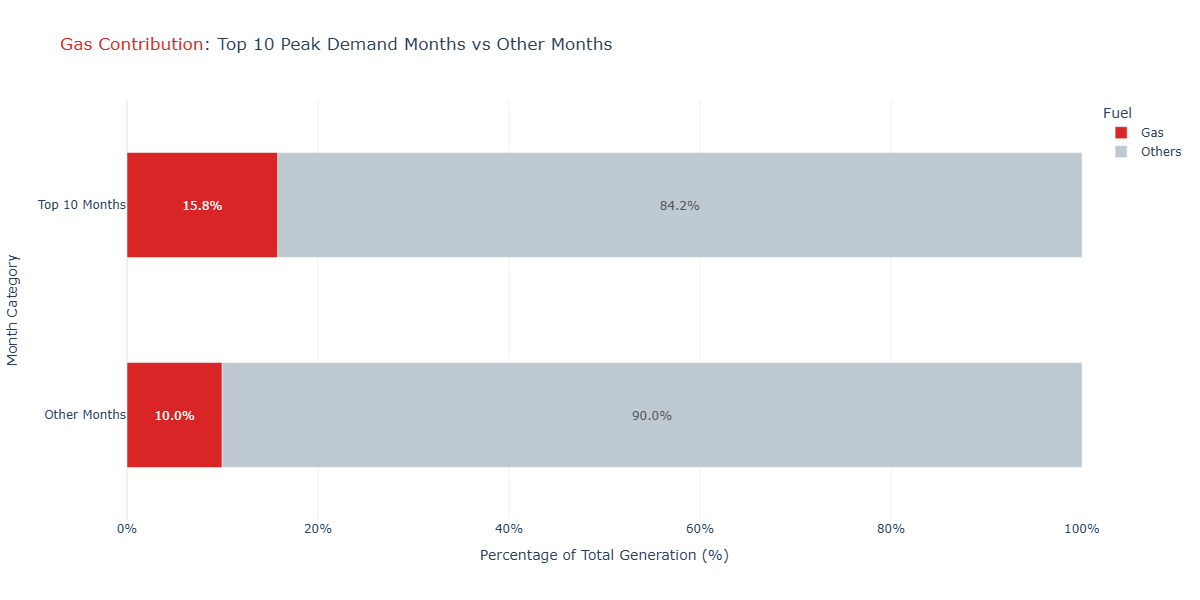

In [25]:
# Creating a horizontal bar chart to compare Gas' contribution to the grid vs all other fuels for Top 10 peak demand months vs rest of the months.

bar = px.bar(
    data_frame=df_top_10_peak,
    x='percentage_of_total_generation',
    y='month_category',
    color='fuel_category',
    color_discrete_map={
        'Gas': GLOBAL_COLOR_PALETTE['Gas'],
        'Others': '#BFC9D1'
    },
    labels={
        'month_category': 'Month Category',
        'percentage_of_total_generation': 'Percentage of Total Generation (%)',
        'fuel_category': 'Fuel'
    },
    category_orders={
        'month_category': ['Top 10 Months', 'Other Months']
    },
    title=f"<span style='color:{GLOBAL_COLOR_PALETTE['Gas']}'>Gas Contribution</span>: Top 10 Peak Demand Months vs Other Months",
    width=1200,
    height=600,
)

bar.update_traces(
    hovertemplate="<b>%{x:.2f}%</b>",
    texttemplate="%{x:.1f}%",          # Formats the label
    textposition="inside",             # Forces the label inside the segment
    insidetextanchor="middle",         # Centers the text within that segment
    textfont_color="#FFFFFF",
)

bar.update_traces(
    selector=dict(name="Others"),
    textfont_color="#555555",
)

bar.update_layout(
    bargap=0.5,
    template='plotly_white',
    xaxis=dict(range=[0, 100], ticksuffix='%'),
)

# Exports a standalone interactive HTML file for the GitHub Pages chart index
bar.write_html('docs/charts/gas_contribution_top10.html', include_plotlyjs='cdn', full_html=True)
bar.show()

▶ [View interactive version](https://ksprihar.github.io/ontario-energy-mix/charts/gas_contribution_top10.html)

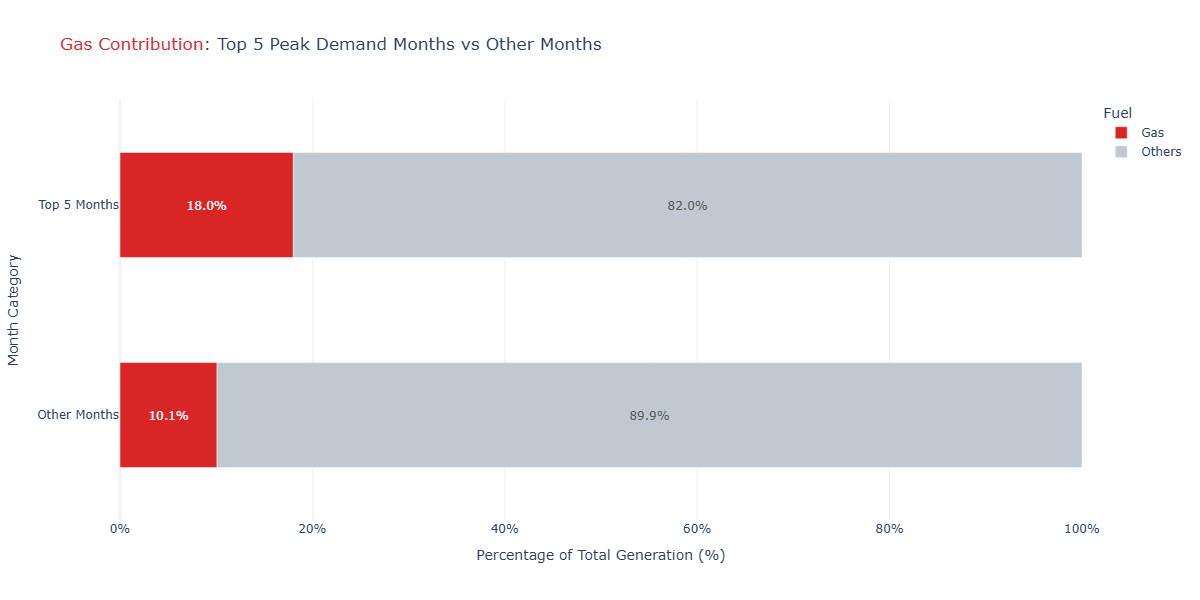

In [26]:
# Creating a horizontal bar chart to compare Gas' contribution to the grid vs all other fuels for Top 5 peak demand months vs rest of the months.

bar = px.bar(
    data_frame=df_top_5_peak,
    x='percentage_of_total_generation',
    y='month_category',
    color='fuel_category',
    color_discrete_map={
        'Gas': GLOBAL_COLOR_PALETTE['Gas'],
        'Others': '#BFC9D1'
    },
    labels={
        'month_category': 'Month Category',
        'percentage_of_total_generation': 'Percentage of Total Generation (%)',
        'fuel_category': 'Fuel'
    },
    category_orders={
        'month_category': ['Top 5 Months', 'Other Months']
    },
    title=f"<span style='color:{GLOBAL_COLOR_PALETTE['Gas']}'>Gas Contribution</span>: Top 5 Peak Demand Months vs Other Months",
    width=1200,
    height=600,
)

bar.update_traces(
    hovertemplate="<b>%{x:.2f}%</b>",
    texttemplate="%{x:.1f}%",          # Formats the label
    textposition="inside",             # Forces the label inside the segment
    insidetextanchor="middle",         # Centers the text within that segment
    textfont_color="#FFFFFF",
)

bar.update_traces(
    selector=dict(name="Others"),
    textfont_color="#555555",
)

bar.update_layout(
    bargap=0.5,
    template='plotly_white',
    xaxis=dict(range=[0, 100], ticksuffix='%'),
)

# Exports a standalone interactive HTML file for the GitHub Pages chart index
bar.write_html('docs/charts/gas_contribution_top5.html', include_plotlyjs='cdn', full_html=True)
bar.show()

▶ [View interactive version](https://ksprihar.github.io/ontario-energy-mix/charts/gas_contribution_top5.html)

The concentration effect expands further: across the **10 months with the highest recorded peak demand**, the grid's reliance on Gas rises to **15.78%**, compared to **9.97%** across all standard operational months. Narrowing the lens to the single most extreme top 5 months, this effect intensifies even further, with Gas's share climbing to **18.02%** — suggesting the relationship strengthens, not weakens, as demand stress becomes more extreme.

Together with the 50th-percentile split, this gives a consistent, monotonic pattern: Gas's share of generation rises in step with the severity of demand stress (7.8% → 12.8% → 15.8% → 18.0%), strengthening confidence that this is a genuine structural relationship rather than noise from any single threshold choice.

**One caveat worth flagging:** 3 of the top 5 months (June, July, and August) all fall within summer 2025, meaning this specific extreme-end result may be partly driven by one unusually hot season rather than a fully generalizable pattern. The broader Top 10 and 50th-percentile splits — which draw from a wider set of years — are the more robust evidence for the underlying relationship, with the Top 5 figure serving as a supporting data point rather than the primary claim.

Although an exploration of the hourly data instead of monthly would be a more definitive proof that gas is indeed what makes up for the peak demands, there is enough evidence presented in this report to say that there is a relationship between months with peaking demand and increasing gas output. The exploration of the hourly data will be done at a future date.


## 7. Looking Ahead: The Policy and Environmental Outlook

While Ontario successfully eliminated coal in 2014, natural gas remains an active component of our electricity landscape. Though natural gas emits roughly 50% less CO₂ than coal when burned (per U.S. Energy Information Administration figures), continued reliance on it still carries meaningful emissions implications — particularly given methane leakage during extraction, a far more potent greenhouse gas in the short term.

Currently sitting at just under 20% of the generation mix during modern tracking windows, gas has shifted from a pure "peaker" fuel into a structural baseload fallback asset.

### The Long-Term Plan (Out to 2050):
Ontario's *Energy for Generations* Integrated Energy Plan projects electricity demand to grow by roughly **75% by 2050**, and leans on two pillars to meet it — natural gas in the short term, and a major nuclear expansion in the long term.

* **2026 - 2030 (The Short-Term Squeeze):** As a significant portion of Ontario's nuclear fleet undergoes scheduled refurbishment, gas use is expected to remain well above typical levels. Independent analysis of the plan estimates gas generation scaling up by nearly 50%, filling roughly a quarter of the province's electricity needs by 2030.
* **2030 - 2050 (The Deep Decarbonization Window):** As refurbished and newly commissioned nuclear capacity comes online, the plan anticipates gas usage scaling back toward a minimal peaker role, with renewed baseload nuclear displacing gas on the grid.

### Critical Analytical Inquiries for Future Research:
1. **Asset Diversification Strategy:** Ontario's roadmap leans heavily on large-scale nuclear assets. Critics — notably the Pembina Institute — argue this is a "risky bet," contending that expanding utility-scale wind, solar, and storage could meet demand more affordably and with less schedule risk, citing nuclear's history of cost overruns and delays. Is this critique borne out by the data, or do nuclear's reliability and baseload characteristics justify the approach?
2. **Economic Impacts:** How will consumer electricity rate structures respond as the province directs significant capital into large-scale nuclear overhauls and continued gas reliance?

*These systemic questions provide the foundational scope for upcoming portfolio projects.*

---
*Sources: Demand growth, refurbishment timeline, and gas-to-nuclear transition narrative from the Government of Ontario's [Energy for Generations Integrated Energy Plan](https://www.ontario.ca/page/energy-generations) (June 2025). The "~50% gas increase to a quarter of supply by 2030" estimate and the affordability critique are from the Pembina Institute's analysis, [Ontario takes a risky bet on energy bills...](https://www.pembina.org/blog/ontario-takes-risky-bet-energy-bills-too-much-emphasis-nuclear-gas) (Dec 2025) — an environmental advocacy organization's assessment, not a neutral source. CO₂ comparison per U.S. EIA figures, via [MET Group](https://met.com/en/mind-the-fyouture/mindthefyouture/natural-gas-vs-coal/).*